/tmp/ipykernel_32959/1209215183.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


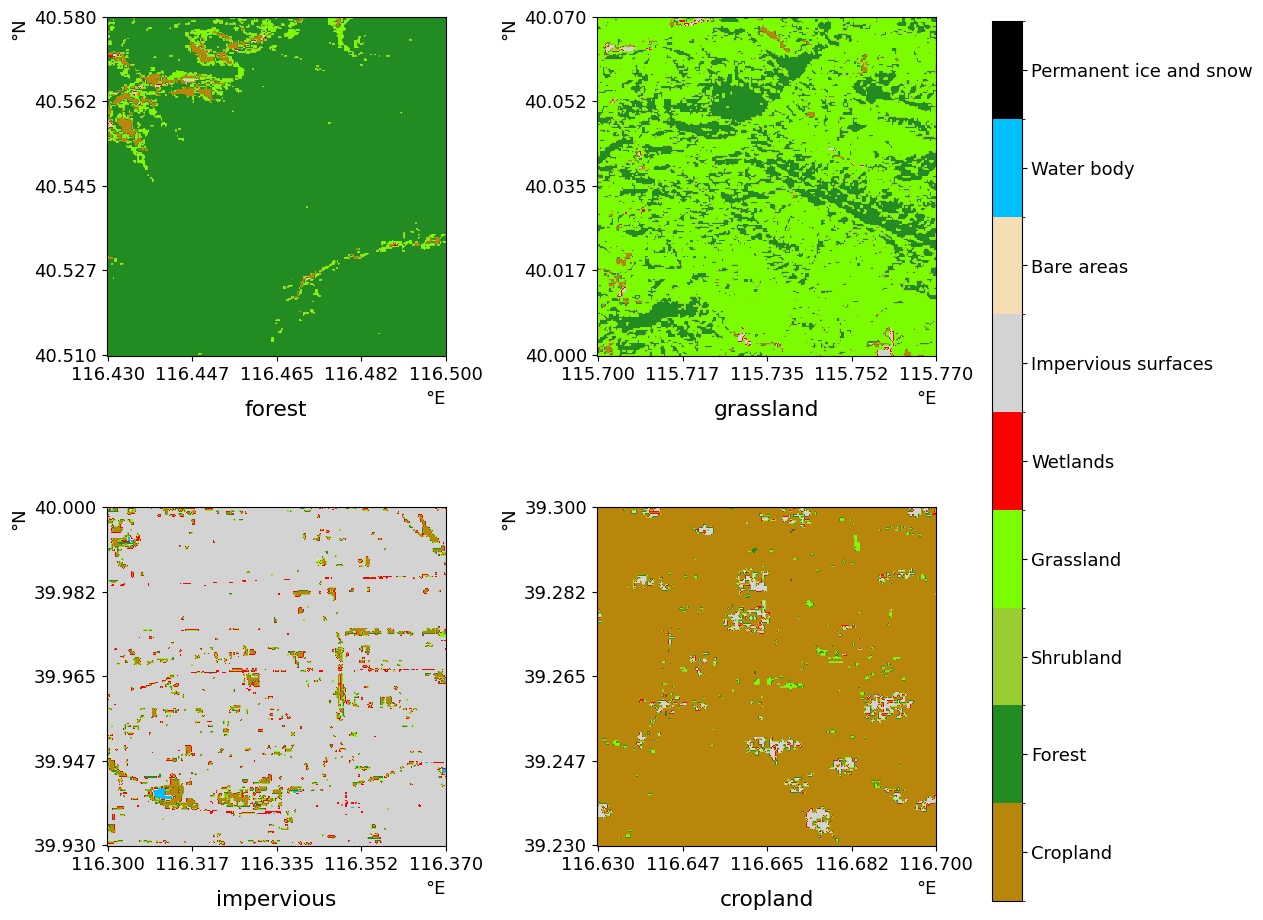

In [35]:
from tifffile import TiffFile
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.axes import Axes
import numpy as np

plt.rcParams.update({"font.size": 13})

class Landcover(object):
    def __init__(self) -> None:
        up = "/home/sakura/p5/aux/landcover/GLC_FCS30_2020_E115N45.tif"
        down = "/home/sakura/p5/aux/landcover/GLC_FCS30_2020_E115N40.tif"
        with TiffFile(up) as i1:
            with TiffFile(down) as i2:
                self.data = np.vstack((i1.pages[0].asarray(), i2.pages[0].asarray()))
            self.shape = self.data.shape
            _, _, _, self.left, self.top, _ = i1.pages[0].tags.get('ModelTiepointTag').value
            self.dx, self.dy, _ = i1.pages[0].tags.get('ModelPixelScaleTag').value

    def find(self, lon, lat):
        i = (self.top - lat) / self.dy
        j = (lon - self.left) / self.dx
        row, col = np.uint32(i), np.uint32(j)
        return self.data[row, col]
    
    @classmethod
    def mapColor(cls, data):
        data[(data >= 10) & (data <= 20)] = 1
        data[(data >= 50) & (data <= 90)] = 2
        data[(data >= 120) & (data < 130)] = 3
        data[(data == 130)] = 4
        data[(data == 180)] = 5
        data[(data == 190)] = 6
        data[((data >= 140) & (data < 160)) | ((data >= 200) & (data < 210))] = 7
        data[(data == 210)] = 8
        data[(data == 220)] = 9

        colors = ["darkgoldenrod", "forestgreen", "yellowgreen", "lawngreen", "red", "lightgrey", "wheat", "deepskyblue", "black"]
        cmap = ListedColormap(colors)
        ticks = np.arange(1, 10, 1, dtype=np.int8)
        norm = BoundaryNorm(np.arange(0.5, 9.6, 1, dtype=np.float32), len(colors))
        labels = ["Cropland", "Forest", "Shrubland", "Grassland", "Wetlands", "Impervious surfaces", "Bare areas", "Water body", "Permanent ice and snow"]
        return cmap, norm, ticks, labels
    
    @classmethod
    def imshow(self, data, ax: Axes,ticks, labels, lower=False):
        cmap, norm, cticks, clabels = Landcover.mapColor(data)
        img = ax.imshow(data, cmap=cmap, norm=norm, origin="lower" if lower else "upper")
        ax.set_xticks(ticks['x'], labels['x'])
        ax.set_yticks(ticks['y'], labels['y'])
        ax.set_xlabel("°E", loc="right")
        ax.set_ylabel("°N", loc="top")
        return img
        # plt.colorbar(ticks=cticks).set_ticklabels(clabels)


class Region(object):
    @classmethod
    def meshgrid(cls, top, left, bottom, right, resolution=30e-5,nTicks=5):
        lon = np.arange(left, right, resolution)
        lat = np.arange(bottom, top, resolution)
        xticks = np.linspace(0.5, len(lon)-0.5, nTicks)
        yticks = np.linspace(0.5, len(lat)-0.5, nTicks)
        xlabels = ["%.3f" % i for i in np.linspace(lon[0], lon[-1], nTicks)]
        ylabels = ["%.3f" % i for i in np.linspace(lat[0], lat[-1], nTicks)]
        lon, lat = np.meshgrid(lon, lat)
        return lon, lat, xticks, yticks, xlabels, ylabels

    @classmethod
    def forest(cls):
        # return cls.meshgrid(40.6, 116.4, 40.5, 116.8) # 3, 9 / 3, 8
        return cls.meshgrid(40.58, 116.43, 40.51, 116.5)
    
    @classmethod
    def grassland(cls):
        # return cls.meshgrid(40.1, 115.7, 40, 115.85) # 2, 6 / 2, 5
        return cls.meshgrid(40.07, 115.7, 40, 115.77)
    
    @classmethod
    def impervious(cls):
        # return cls.meshgrid(40, 116.3,39.9,116.45) # 3, 5
        return cls.meshgrid(40, 116.3,39.93,116.37)
    
    @classmethod
    def cropland(cls):
        # return cls.meshgrid(39.45, 116.5,39.2,116.8) # 3, 2 / 3, 1
        return cls.meshgrid(39.3, 116.63,39.23,116.7)


def main():
    landcover = Landcover()
    fig, axes = plt.subplots(2,2,figsize=(10,10))
    cticks, clabels, img = None, None, None
    for i, ax in zip(('forest', 'grassland', 'impervious', 'cropland'), axes.ravel()):
        lon, lat, xticks, yticks, xlabels, ylabels = getattr(Region, i)()
        res = landcover.find(lon, lat)
        img = Landcover.imshow(res, ax, {'x':xticks, 'y':yticks}, {'x':xlabels, 'y':ylabels}, True)
        ax.set_title(i, y=-0.2)
        _, _, cticks, clabels = Landcover.mapColor(res)
    cax = fig.add_axes([1,0.06,0.03,0.88])
    fig.colorbar(img, cax=cax, ticks=cticks).set_ticklabels(clabels)
    plt.tight_layout()
    plt.show()


main()